In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# 1. Installing Roboflow

In [1]:
!pip install roboflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 40.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 127.7 MB/s eta 0:00:0000:01


# 2. Downloading our DataSet

In [2]:
from roboflow import Roboflow
rf = Roboflow(api_key="OLT1vTqCJKowRk672K0o")
project = rf.workspace("mirajverisk-s-workspace").project("my-first-project-2-cphbh")
version = project.version(1)
dataset = version.download("yolov11")     

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to My-First-Project-2-1 in yolov11:: 100%|██████████| 397/397 [00:00<00:00, 11320.85it/s]


# 3. Looking For the Configurations

In [3]:
import yaml
from pprint import pprint

yaml_path = "/kaggle/working/My-First-Project-2-1/data.yaml"

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

pprint(data)

{'names': ['mask', 'no mask', 'phone'],
 'nc': 3,
 'roboflow': {'license': 'CC BY 4.0',
              'project': 'my-first-project-2-cphbh',
              'url': 'https://universe.roboflow.com/mirajverisk-s-workspace/my-first-project-2-cphbh/dataset/1',
              'version': 1,
              'workspace': 'mirajverisk-s-workspace'},
 'test': '../test/images',
 'train': '../train/images',
 'val': '../valid/images'}


# 4. Change the Path

#### This is how our current data directory looks like

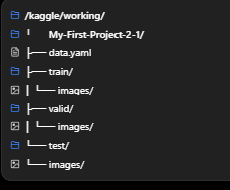

#### Change `../train/images`, `../valid/images`, and `../test/images` to `train/images`, `valid/images`, and `test/images` because the folders and `data.yaml` are in the same directory.
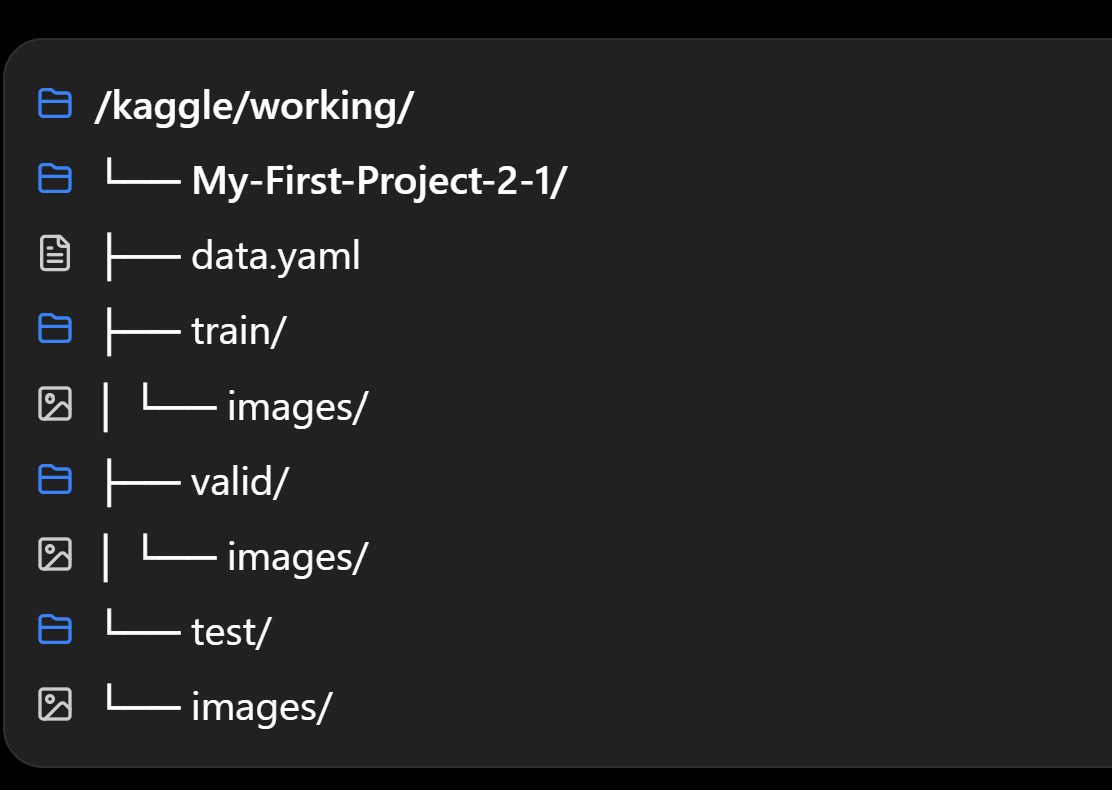

In [4]:
import yaml

yaml_path = "/kaggle/working/My-First-Project-2-1/data.yaml"

# Read
with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

# Update paths
data["train"] = "train/images"
data["val"] = "valid/images"
data["test"] = "test/images"

# Save
with open(yaml_path, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("Updated data.yaml")

Updated data.yaml


# 5. Check the Updatation

In [5]:
import yaml
from pprint import pprint

yaml_path = "/kaggle/working/My-First-Project-2-1/data.yaml"

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

pprint(data)

{'names': ['mask', 'no mask', 'phone'],
 'nc': 3,
 'roboflow': {'license': 'CC BY 4.0',
              'project': 'my-first-project-2-cphbh',
              'url': 'https://universe.roboflow.com/mirajverisk-s-workspace/my-first-project-2-cphbh/dataset/1',
              'version': 1,
              'workspace': 'mirajverisk-s-workspace'},
 'test': 'test/images',
 'train': 'train/images',
 'val': 'valid/images'}


# 6. Fine tune the Model on Custom Data

In [6]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.9 MB/s eta 0:00:0000:01


In [7]:
from ultralytics import YOLO

# Load pretrained YOLO11 model
model = YOLO("yolo11n.pt")

yaml_path = r"/kaggle/working/My-First-Project-2-1/data.yaml"

# Train
results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,      # gpu - 0 / cpu - "cpu",
    name="custom_yolo11",
    pretrained=True,
    optimizer="auto",
    patience=20,
    save=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/My-First-Project-2-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h

### Chcek For Results all the Results Will be Saving Inside `runs` folder

` inside run folders we can see metrices and model weights`

In [8]:
import shutil

shutil.make_archive(
    "/kaggle/working/runs",
    "zip",
    "/kaggle/working/runs"
)

'/kaggle/working/runs.zip'

# 7. Test on the Fine tuned Model

In [9]:
test_image_path = r"/kaggle/working/My-First-Project-2-1/train/images/10_jpg.rf.27ce7bbeed197b4412108161fc163e68.jpg"

# Load Fine Tuned model
model = YOLO(r"/kaggle/working/runs/detect/custom_yolo11/weights/best.pt")

# Train
results = model(test_image_path)


image 1/1 /kaggle/working/My-First-Project-2-1/train/images/10_jpg.rf.27ce7bbeed197b4412108161fc163e68.jpg: 640x640 1 phone, 11.8ms
Speed: 4.6ms preprocess, 11.8ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


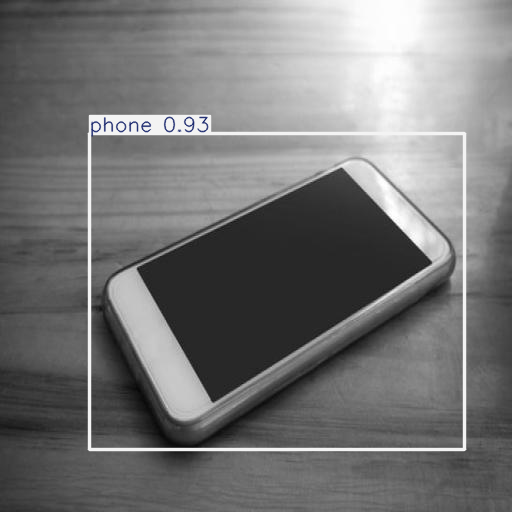

In [11]:
results[0].show()